Error summary:


,classification_type,frequency_pct,model_missed_pct,raw_errors
0,punycode,0.081748,0.000000,0
1,non_ascii,64.070703,0.724905,767
2,unicode_homoglyph,18.174772,0.000000,0
3,hyphen_change,6.330348,2.974938,311
4,digit_change,6.029999,5.683872,566
5,transposition,0.727863,0.998336,12
6,insertion,39.675187,4.278083,2803
7,deletion,11.762676,8.000000,1554
8,substitution,82.267880,3.327739,4521
9,digit_substitution,1.251052,5.856728,121



Average string length buckets:


,avg_string_length_bucket_start,avg_string_length_bucket_end,avg_string_length_bucket_mean,accuracy_pct,frequency_pct
0,0.5,6.0,4.748798,90.719748,25.755393
1,6.0,7.5,7.005342,95.302114,15.520114
2,7.5,9.5,8.672913,97.263113,21.790210
3,9.5,12.0,10.884609,98.189342,20.037293
4,12.0,54.5,15.090241,98.990923,16.896989



Absolute length difference buckets:


,abs_length_difference_bucket_start,abs_length_difference_bucket_end,abs_length_difference_bucket_mean,accuracy_pct,frequency_pct
0,0,2,0.374614,96.945436,90.457851
1,2,4,2.117027,93.133211,9.541543
2,4,6,5.000000,100.000000,0.000606



Merged absolute length difference buckets:


,abs_length_difference_bucket_start,abs_length_difference_bucket_end,accuracy_pct,frequency_pct,bucket_mid
0,0,4,96.581689,99.999394,2.0
1,4,8,100.000000,0.000606,6.0


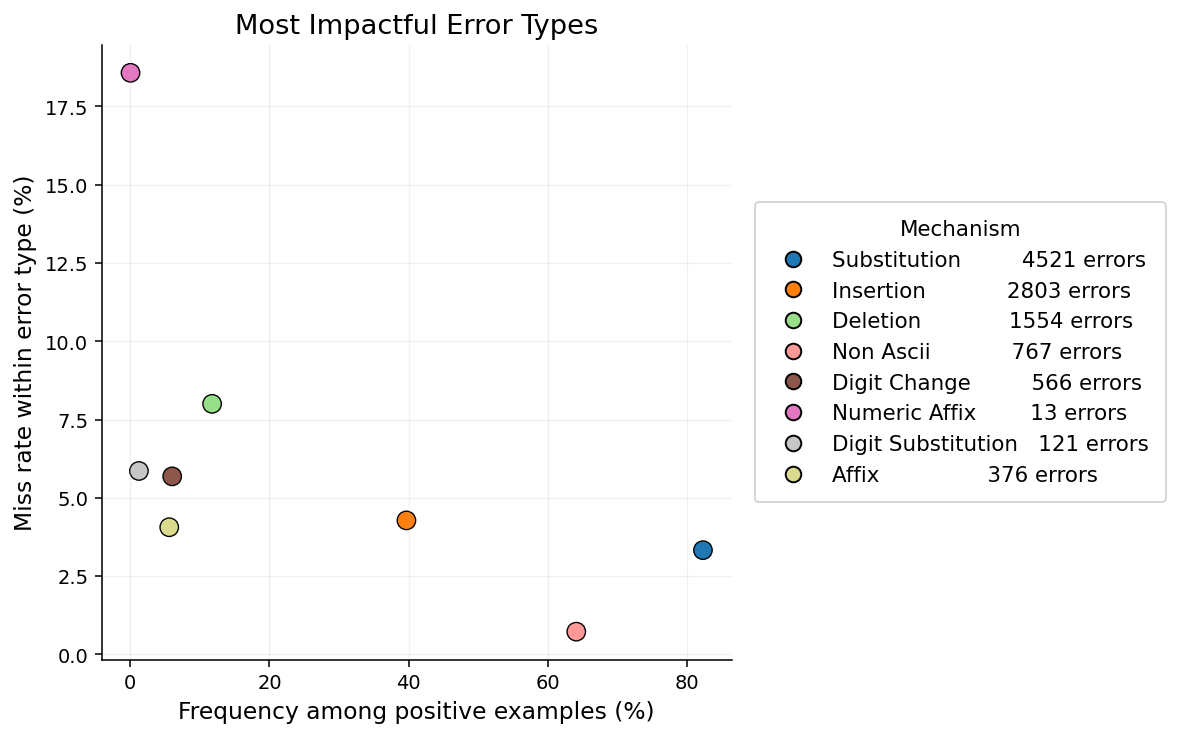

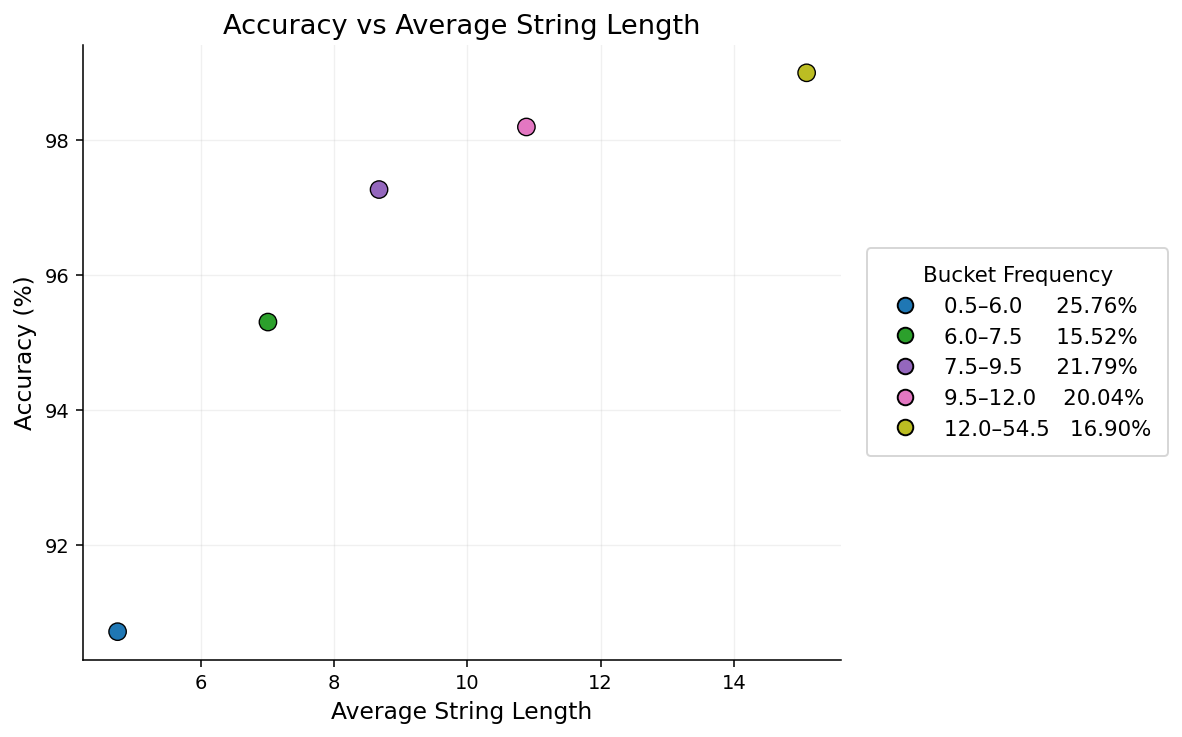

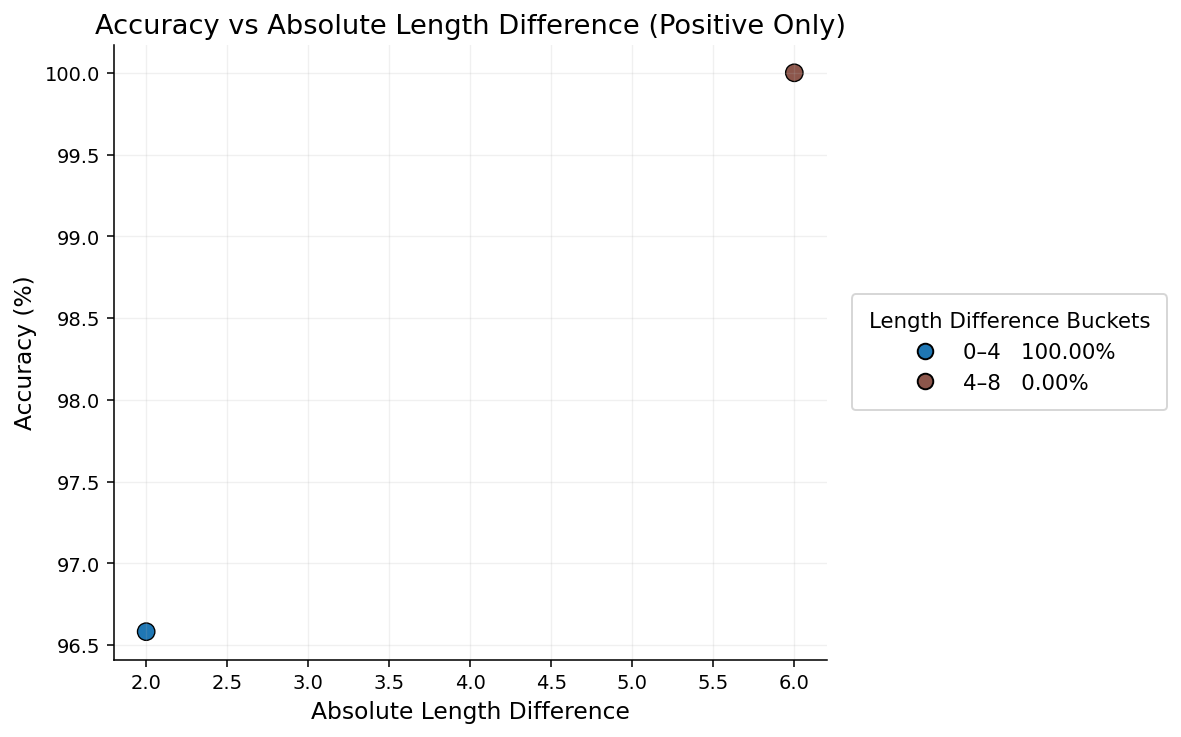

In [63]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.lines import Line2D


ERROR_SUMMARY_PATH = Path("total_5f_error_type_summary.txt")
AVG_LEN_PATH = Path("total_5f_accuracy_by_avg_string_length.txt")
ABS_DIFF_PATH = Path("total_5f_accuracy_by_abs_length_difference.txt")


# Restored coarser buckets for the last graph only
ABS_DIFF_MERGED_BINS = [
    (0, 4),
    (4, 8),
    (8, 12),
    (12, 18),
    (18, 38),
]


plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.18,
})


def read_pipe_table(path):
    df = pd.read_csv(path, sep="|", engine="python")
    df.columns = [c.strip() for c in df.columns]

    for c in df.columns:
        if df[c].dtype == object:
            df[c] = df[c].astype(str).str.strip()

    return df


def clean_name(x):
    return x.replace("_", " ").title()


def generate_colors(n):
    cmap = plt.get_cmap("tab20")
    return [cmap(i / max(n, 1)) for i in range(n)]


def build_legend(ax, labels, values, colors, title):
    handles = []

    max_label = max(len(l) for l in labels)

    for lab, val, col in zip(labels, values, colors):
        text = f"{lab:<{max_label}}   {val}"

        handles.append(
            Line2D(
                [0], [0],
                marker="o",
                color="w",
                markerfacecolor=col,
                markeredgecolor="black",
                markersize=8,
                label=text,
            )
        )

    ax.legend(
        handles=handles,
        title=title,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
        borderpad=0.8,
    )


def merge_abs_diff_buckets(df, bins):
    rows = []

    for lo, hi in bins:
        sub = df[
            (df["abs_length_difference_bucket_start"] >= lo) &
            (df["abs_length_difference_bucket_end"] <= hi)
        ].copy()

        freq_pct = float(sub["frequency_pct"].sum())

        if freq_pct > 0:
            acc_pct = float((sub["accuracy_pct"] * sub["frequency_pct"]).sum() / freq_pct)
        else:
            acc_pct = np.nan

        rows.append({
            "abs_length_difference_bucket_start": lo,
            "abs_length_difference_bucket_end": hi,
            "accuracy_pct": acc_pct,
            "frequency_pct": freq_pct,
        })

    out = pd.DataFrame(rows)
    out["bucket_mid"] = (
        out["abs_length_difference_bucket_start"] +
        out["abs_length_difference_bucket_end"]
    ) / 2.0

    return out.dropna(subset=["accuracy_pct"]).reset_index(drop=True)


# =====================================================
# ERROR TYPE SCATTER
# =====================================================

def plot_error_type_scatter(df):
    plot_df = df.dropna(subset=["frequency_pct", "model_missed_pct", "raw_errors"]).copy()

    top_raw = plot_df.sort_values("raw_errors", ascending=False).head(5)

    top_miss = (
        plot_df
        .sort_values("model_missed_pct", ascending=False)
        .loc[~plot_df["classification_type"].isin(top_raw["classification_type"])]
        .head(3)
    )

    plot_df = pd.concat([top_raw, top_miss]).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(8.6, 5.4))

    x = plot_df["frequency_pct"]
    y = plot_df["model_missed_pct"]

    colors = generate_colors(len(plot_df))

    ax.scatter(
        x,
        y,
        s=90,
        c=colors,
        edgecolor="black",
        linewidth=0.7,
    )

    labels = [clean_name(v) for v in plot_df["classification_type"]]
    values = [f"{int(v)} errors" for v in plot_df["raw_errors"]]

    build_legend(ax, labels, values, colors, "Mechanism")

    ax.set_xlabel("Frequency among positive examples (%)")
    ax.set_ylabel("Miss rate within error type (%)")
    ax.set_title("Most Impactful Error Types")

    ax.grid(True)

    plt.tight_layout()
    plt.show()


# =====================================================
# AVG STRING LENGTH
# =====================================================

def plot_avg_length(df):
    fig, ax = plt.subplots(figsize=(8.6, 5.4))

    x = df["avg_string_length_bucket_mean"]
    y = df["accuracy_pct"]

    colors = generate_colors(len(df))

    ax.scatter(
        x,
        y,
        s=80,
        c=colors,
        edgecolor="black",
        linewidth=0.7,
    )

    labels = []
    values = []

    for _, row in df.iterrows():
        rng = f"{row['avg_string_length_bucket_start']}–{row['avg_string_length_bucket_end']}"
        labels.append(rng)
        values.append(f"{row['frequency_pct']:.2f}%")

    build_legend(ax, labels, values, colors, "Bucket Frequency")

    ax.set_xlabel("Average String Length")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Accuracy vs Average String Length")

    ax.grid(True)

    plt.tight_layout()
    plt.show()


# =====================================================
# ABSOLUTE LENGTH DIFFERENCE (MERGED BUCKETS RESTORED)
# =====================================================

def plot_length_diff(df):
    merged_df = merge_abs_diff_buckets(df, ABS_DIFF_MERGED_BINS)

    fig, ax = plt.subplots(figsize=(8.6, 5.4))

    x = merged_df["bucket_mid"]
    y = merged_df["accuracy_pct"]

    colors = generate_colors(len(merged_df))

    ax.scatter(
        x,
        y,
        s=80,
        c=colors,
        edgecolor="black",
        linewidth=0.7,
    )

    labels = []
    values = []

    for _, row in merged_df.iterrows():
        rng = (
            f"{int(row['abs_length_difference_bucket_start'])}"
            f"–"
            f"{int(row['abs_length_difference_bucket_end'])}"
        )
        labels.append(rng)
        values.append(f"{row['frequency_pct']:.2f}%")

    build_legend(ax, labels, values, colors, "Length Difference Buckets")

    ax.set_xlabel("Absolute Length Difference")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Accuracy vs Absolute Length Difference (Positive Only)")

    ax.grid(True)

    plt.tight_layout()
    plt.show()


# =====================================================
# LOAD FILES
# =====================================================

error_df = read_pipe_table(ERROR_SUMMARY_PATH)
avg_len_df = read_pipe_table(AVG_LEN_PATH)
abs_diff_df = read_pipe_table(ABS_DIFF_PATH)


for c in ["frequency_pct", "model_missed_pct", "raw_errors"]:
    error_df[c] = pd.to_numeric(error_df[c], errors="coerce")

for c in [
    "avg_string_length_bucket_start",
    "avg_string_length_bucket_end",
    "avg_string_length_bucket_mean",
    "accuracy_pct",
    "frequency_pct",
]:
    avg_len_df[c] = pd.to_numeric(avg_len_df[c], errors="coerce")

for c in [
    "abs_length_difference_bucket_start",
    "abs_length_difference_bucket_end",
    "accuracy_pct",
    "frequency_pct",
]:
    abs_diff_df[c] = pd.to_numeric(abs_diff_df[c], errors="coerce")


print("Error summary:")
display(error_df)

print("\nAverage string length buckets:")
display(avg_len_df)

print("\nAbsolute length difference buckets:")
display(abs_diff_df)

print("\nMerged absolute length difference buckets:")
display(merge_abs_diff_buckets(abs_diff_df, ABS_DIFF_MERGED_BINS))


plot_error_type_scatter(error_df)
plot_avg_length(avg_len_df)
plot_length_diff(abs_diff_df)